# Explainability: Isolation Forest

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_auc_score, average_precision_score
import joblib
import plotly.express as px
from sklearn.decomposition import PCA
import shap


/Users/taxi/miniconda3/envs/consoning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data

In [2]:
isof = joblib.load('../models/isolation_forest_model.joblib')
test = pd.read_csv('../data/processed/if_test.csv')
train = pd.read_csv('../data/processed/if_train.csv')

Xtrain = train.drop('is_attack',axis=1)
ytrain = train['is_attack']

Xtest = test.drop('is_attack',axis=1)
ytest = test['is_attack']

In [3]:
scaler = isof.named_steps['scaler']
isolation_forest = isof.named_steps['if']

X_train_scaled = pd.DataFrame(
    scaler.transform(Xtrain), 
    columns=Xtrain.columns, 
    index=Xtrain.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(Xtest), 
    columns=Xtest.columns, 
    index=Xtest.index
)

train_anomaly_scores = -isolation_forest.score_samples(X_train_scaled)
test_anomaly_scores = -isolation_forest.score_samples(X_test_scaled)


/Users/taxi/miniconda3/envs/consoning/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(
/Users/taxi/miniconda3/envs/consoning/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


## Interpretacion global

In this part SHAP will be used for local and global explainability. The explainability will focus in the testing set

In [4]:
explainer = shap.TreeExplainer(isolation_forest)

shap_values = explainer.shap_values(X_test_scaled)

shap_values_inverted = -shap_values

feature_importance = np.mean(np.abs(shap_values_inverted), axis=0)
feature_names = X_test_scaled.columns
top_10_indices = np.argsort(feature_importance)[-10:][::-1]  # descendente

# 4. Filtrar datos a top 10
X_top10 = X_test_scaled.iloc[:, top_10_indices]
shap_top10 = shap_values_inverted[:, top_10_indices]

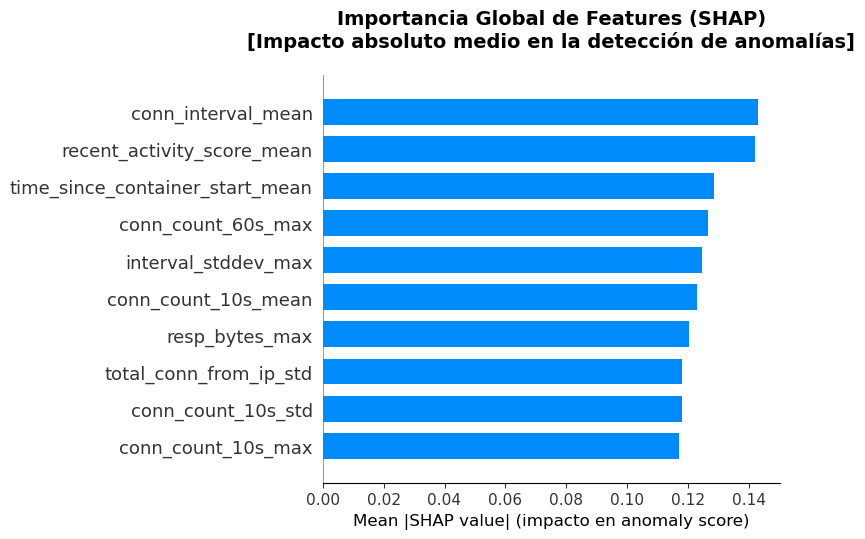

In [5]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_top10, X_top10, plot_type="bar", show=False)
plt.title("Importancia Global de Features (SHAP)\n[Impacto absoluto medio en la detección de anomalías]", 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Mean |SHAP value| (impacto en anomaly score)", fontsize=12)
plt.tight_layout()
plt.savefig('../reports/figures/shap_global_importance_bar.png', dpi=300, bbox_inches='tight')
plt.show()


- The previous plot shows the 10 most important variables for the model to detect anomalies.
- In the top, we can see **conn_interval_mean**, **time_since_container_start_mean**, **conn_count_60s_max**, **recent_activity_score_mean**, **interval_stddev_max**. There are also some other important features that are also related to the intensity of connections.
- These visualizations do not show if the features are impacting to increase the anomaly score or reduce it. This will be visible in the next visualization.

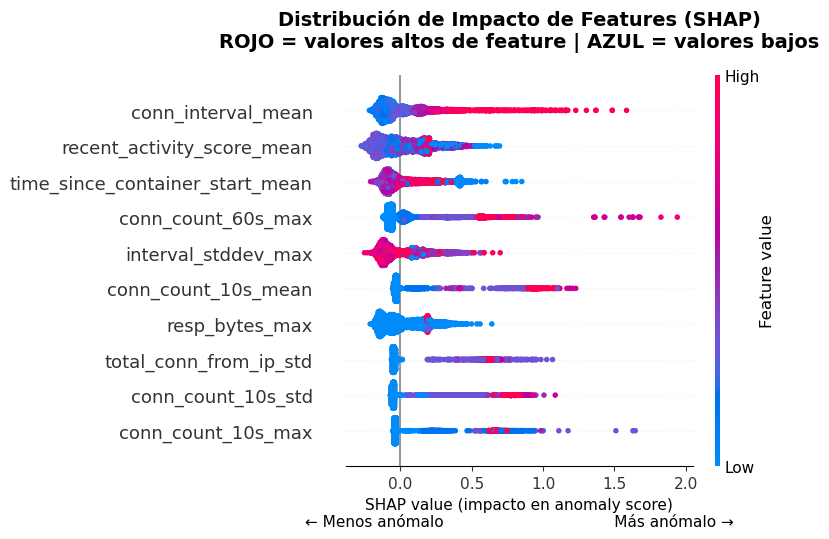

In [6]:
plt.figure(figsize=(14, 10))
shap.summary_plot(shap_top10, X_top10, show=False)
plt.title("Distribución de Impacto de Features (SHAP)\n" + 
          "ROJO = valores altos de feature | AZUL = valores bajos", 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("SHAP value (impacto en anomaly score)\n← Menos anómalo                                   Más anómalo →", 
           fontsize=11)

plt.tight_layout()
plt.savefig('../reports/figures/shap_global_summary.png', dpi=300, bbox_inches='tight')
plt.show()

Here we get a better granularity of the importance of each top feature

- **conn_interval_mean** is a variable that represents the interval between the present connection and the last one. The plot shows that the more anomalous samples have a higher **conn_interval**. Attacks are spontanious events and act in bursts. Other legitimate traffic have keep_alive activated and keep periodic healthcheck with Consul so if these connections go down, the usually are restored in short periods of time. 
- **time_since_container_start_mean**: this feature shows the time that has passed since the last container started. It shows that packets that have been sent to Consul recently, taking as reference a docker containter start, are related to anomalies. Healthcheck and and GET requests to Consul can happen at any time and so do attack. In the other hand, service restarts (docker restarts) are also few and may be considered anomalies and they include registration in Consul.
- **conn_count_60s_max** shows that more connections tend to be related to anomalies by the model. This is self-explainatory as the normal traffic has 1 connection and service restarts, selfregisters and attack have more connections.

- **recent_activity_score_mean**, **interval_stddev_max**, **resp_bytes_max** does not show a clear pattern, it will be analized in a dependence plot.

- the rest of features are variations of the mentioned ones.(Ex: conn_count_60s_max is more or less the same idea as conn_count_10s_mean, conn_count_10s_std, conn_count_10s_max)

<Figure size 1600x600 with 0 Axes>

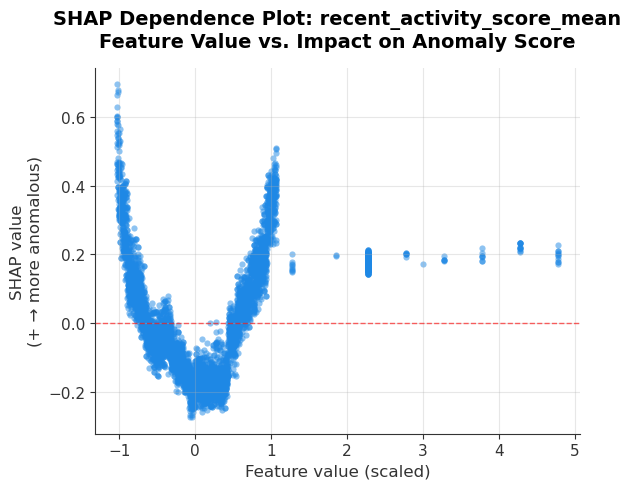

<Figure size 1600x600 with 0 Axes>

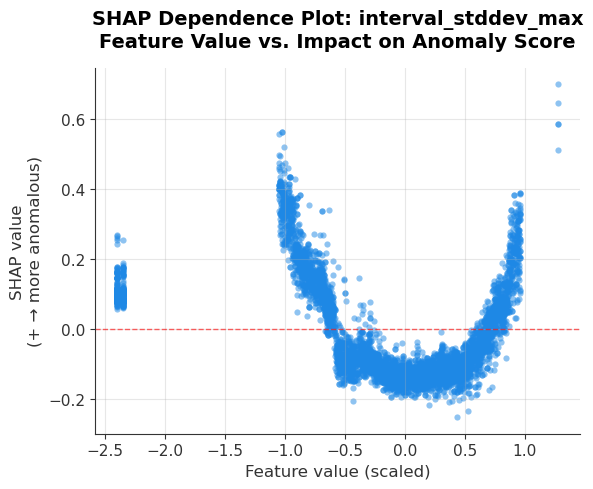

<Figure size 1600x600 with 0 Axes>

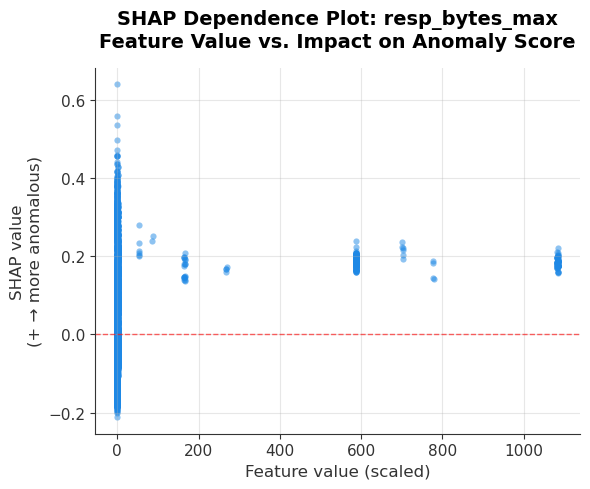

In [14]:
import matplotlib.pyplot as plt

# Lista de features a visualizar
features = [
    'recent_activity_score_mean',
    'interval_stddev_max',
    'resp_bytes_max'
]

# Generar gráfico individual para cada feature
for feature in features:
    feature_idx = Xtest.columns.get_loc(feature)
    
    # Crear figura individual
    plt.figure(figsize=(16, 6))
    
    # Generar dependence plot
    shap.dependence_plot(
        feature_idx,
        shap_values_inverted,
        X_test_scaled,
        interaction_index=None,
        show=False,
        alpha=0.5,
        dot_size=20
    )
    
    # Personalizar
    plt.title(f'SHAP Dependence Plot: {feature}\n'
              'Feature Value vs. Impact on Anomaly Score',
              fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('SHAP value\n(+ → more anomalous)', fontsize=12)
    plt.xlabel('Feature value (scaled)', fontsize=12)
    plt.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.6)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Guardar con nombre específico para cada feature
    filename = feature.lower().replace('_', '-')
    plt.savefig(f'../reports/figures/shap_dependence_{filename}.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()  # Cerrar figura para liberar memoria

- **recent_activity_score_mean**: the first plot shows that both low and high values are related to anomalies. The U pattern suggests that new connections/IP addresses that have no previous traffic and those which have a lot of connections are anomalous as we have seen before.
- **interval_stddev_max**: This variable indicates how regular or irregular the times between connections are. The U pattern show that both very regular and irregular connections can be anomalous. This one is difficult to interpret. Even if we have said that attacks are spontanious events and act in bursts, these are done by software that acts periodically so the attack might have long intervales but regular periodically (letf peek in the plot.) In the other hand, service restarts happen randomly which might explain why irregular intervales between connections are anomalous(the right peak)
- **resp_bytes_max**: No clear pattern is visible, the connections with low **resp_bytes_max** could be both anomalous or normal traffic. Samples with higher **resp_bytes_max**(scaled) than 0 are a bit anomalous. Hypothetically, as attackers usually scan the endpoints of Consul, the response payload should be very heavy so rhe **resp_bytes_max** should be high for attacks.

From the knowledge acquired during the creating phase of the dataset and the Exploratory Data analsys, some hipothesis where made:
- **n_connections** is very predictive and should be related to connection count type of features like **conn_count_60s_max**  and therefore to attacks.
- **burst_score_mean** should be highly related to attack patterns as attackers fetch many endpoints in short periods. Normal:0.0050 ; Attacks:0.8440
- **ja3_frequency** is the feature that shows how many times a same TLS handshake has been seen. During the clustering phase of modeling with GMM this was seen:

    
    Feature                C0 (Legit)  C1_Legit  C1_Attack 

    ja3_frequency_mean     68.1104     68.7149   392.5147

Theoretically this feature should be related to high **conn_count_60s_max** as many connection should mean TLS handshake seen many times.

Let's visualize these features in dependance plots.

<Figure size 1600x600 with 0 Axes>

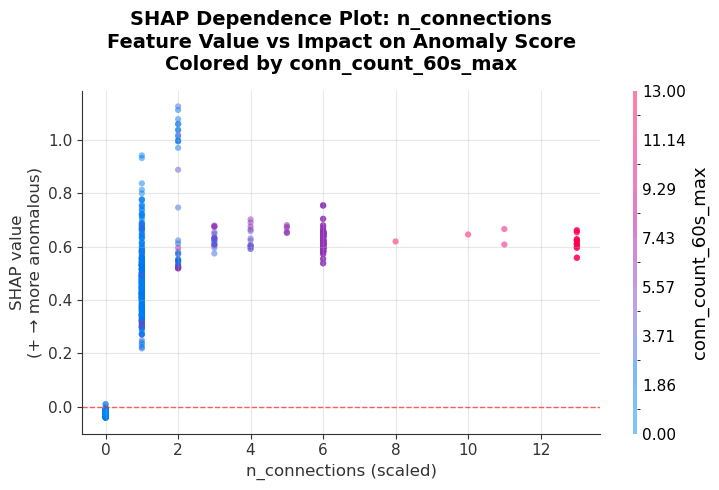

<Figure size 1600x600 with 0 Axes>

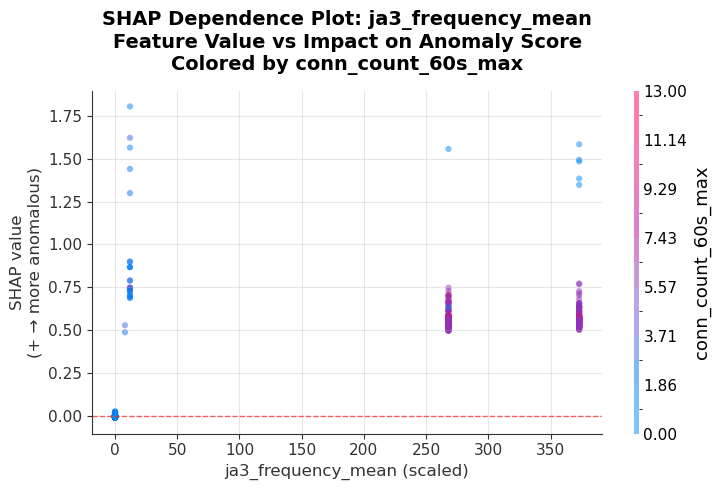

<Figure size 1600x600 with 0 Axes>

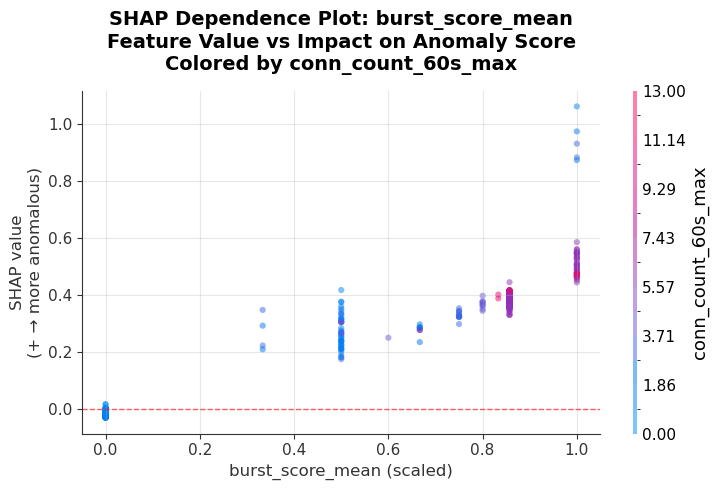

In [19]:
import matplotlib.pyplot as plt
import shap

features_to_plot = [
    'n_connections',
    'ja3_frequency_mean',
    'burst_score_mean'
]

interaction_feature = 'conn_count_60s_max'
interaction_idx = Xtest.columns.get_loc(interaction_feature)

for feature in features_to_plot:
    feature_idx = Xtest.columns.get_loc(feature)

    plt.figure(figsize=(16, 6))

    shap.dependence_plot(
        feature_idx,
        shap_values_inverted,
        X_test_scaled,
        interaction_index=interaction_idx,
        show=False,
        alpha=0.5,
        dot_size=20
    )

    plt.title(
        f'SHAP Dependence Plot: {feature}\n'
        f'Feature Value vs Impact on Anomaly Score\n'
        f'Colored by {interaction_feature}',
        fontsize=14,
        fontweight='bold',
        pad=15
    )

    plt.xlabel(f'{feature} (scaled)', fontsize=12)
    plt.ylabel('SHAP value\n(+ → more anomalous)', fontsize=12)

    plt.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.6)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        f'../reports/figures/shap_dependence_{feature}_colored_by_{interaction_feature}.png',
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


- **n_connections** : 1st plot look like some logarithmic pattern. It can be confirmed that higher **n_connections**, which is the total connections in the window is very related to **conn_count_60s_max**. It also looks like 1 connection (0 after normalizing) is not  anomalous while higher number of connections tend to be more anomalous.
- (2nd plot) As thougth, high **ja3_frequency_mean** is related to high number of connections which is usually more anomalous. This makes sense as the attacks are made by closing the connections after fetching or putting data. The tools used might keep the TLS handshake and increase this **ja3_frequency**
- As said, attacks tend to work in bursts, mostly to scan the endpoints of the Consul. The 3rd plot shows that higher **burst_score_mean** is very related to anomalies and also to higher conn_counts.

## Interpretacion local

Here we will take a look to the most, least and normally anomalous instances via SHAP waterfall plot

In [46]:
# CELDA 1: Setup y función
predictions = isolation_forest.predict(X_test_scaled)

# =============================================================================
# 1. Find instances of interest
# =============================================================================

# Most anomalous
most_anomalous_idx = np.argmax(test_anomaly_scores)

# Least anomalous (most normal)
least_anomalous_idx = np.argmin(test_anomaly_scores)

target_score = 0.55
closest_to_055_idx = np.argmin(np.abs(test_anomaly_scores - target_score))

instances = {
    "Most Anomalous": most_anomalous_idx,
    "Least Anomalous": least_anomalous_idx,
    "Closest to Score=0.55": closest_to_055_idx
}

# =============================================================================
# 2. Función para generar waterfall plot + tabla explicativa
# =============================================================================

def plot_waterfall_and_explain(instance_name, idx):
    print(f"\nGenerating: {instance_name} (index {idx})")
    
    # Create SHAP Explanation object
    explanation = shap.Explanation(
        values=shap_values_inverted[idx],
        base_values=-explainer.expected_value,
        data=X_test_scaled.iloc[idx],
        feature_names=Xtest.columns.tolist()
    )
    
    # Plot
    plt.figure(figsize=(12, 8))
    shap.waterfall_plot(explanation, max_display=6, show=False)
    
    real_label = "ATTACK" if ytest.iloc[idx] == 1 else "LEGITIMATE"
    pred_label = "ANOMALY" if predictions[idx] == -1 else "NORMAL"
    
    plt.title(
        f"Waterfall Plot – {instance_name} (Index {idx})\n"
        f"Anomaly Score: {test_anomaly_scores[idx]:.4f} | "
        f"Prediction: {pred_label} | "
        f"True Label: {real_label}",
        fontsize=13, fontweight='bold', pad=15
    )
    
    plt.tight_layout()
    filename = f"../reports/figures/shap_waterfall_{instance_name.lower().replace(' ', '_')}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    # Detailed explanation table
    instance_shap_df = pd.DataFrame({
        'feature': Xtest.columns,
        'value_original': Xtest.iloc[idx].values,
        'value_scaled': X_test_scaled.iloc[idx].values,
        'shap_value': shap_values_inverted[idx],
        'abs_shap': np.abs(shap_values_inverted[idx])
    }).sort_values('abs_shap', ascending=False)
    
    return instance_shap_df

shap_explanations = {}

/Users/taxi/miniconda3/envs/consoning/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning:

X has feature names, but IsolationForest was fitted without feature names




Generating: Most Anomalous (index 4841)


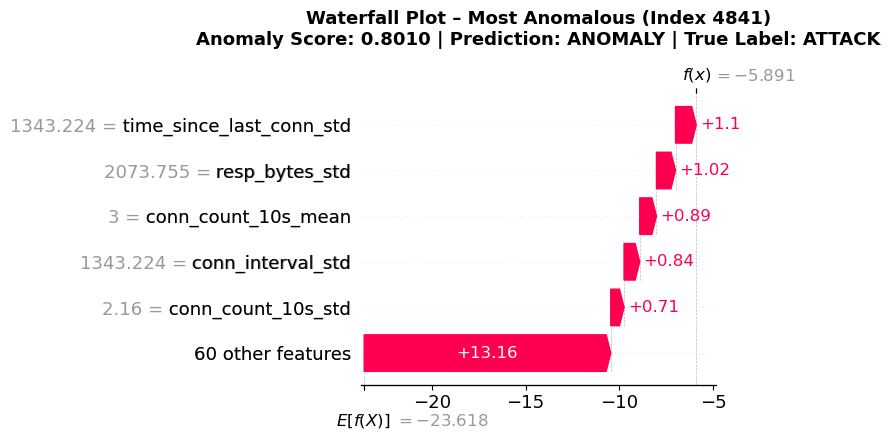

In [40]:
# CELDA 2: Most Anomalous Instance
name = "Most Anomalous"
idx = instances[name]
shap_explanations[name] = plot_waterfall_and_explain(name, idx)

Plot 1:

- From the already mentioned features, high **conn_count_10s_mean** , **conn_interval** shew to be realted to anomalous samples. This plot reaffirms this by adding 0.89 and 0.84 Shapley values respectively. 
- In addition, high **time_since_last_conn_std** (1343) is related to sponstanious action and high intervals which reaffirms what has been proved.
- Finally, **resp_bytes_std** = 2073 tells that at least a packet of that window has ≥2073 **resp_bytes** which is historically high, most of the packets been around 1700. This suggests that our hipothesis where scanning Consul's endpoint responses heavy payload might be correct and relate dto attacks.


Generating: Least Anomalous (index 1515)


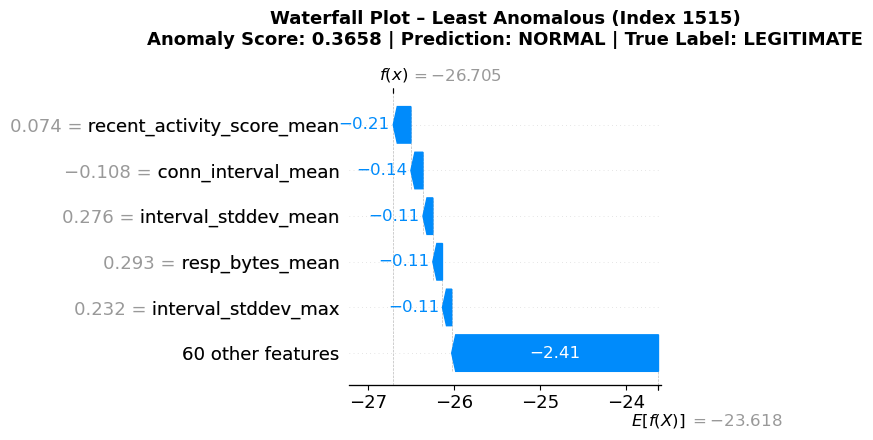

In [42]:
# CELDA 4: Least Anomalous Instance
name = "Least Anomalous"
idx = instances[name]
shap_explanations[name] = plot_waterfall_and_explain(name, idx)

Plot 2:

- **recent_activity_score_mean** are **conn_interval_mean** are around 0. This sample has a normal **recent_activity_score_mean**, it is not a new IP and it is not a very frequent one. It has low **conn_interval_mean** which shows that the downtime is very small or keeps alive teh connection longer periods (maybe healthcheck)
- Low **resp_bytes_mean** make sense as the legitimate services know where to fetch the data they need (ex: https://consul/v1/catalog/service/order) they won't fetch (https://consul/v1/catalog/services). Therefore they would not get heavy payloads.


Generating: Closest to Score=0.55 (index 3647)


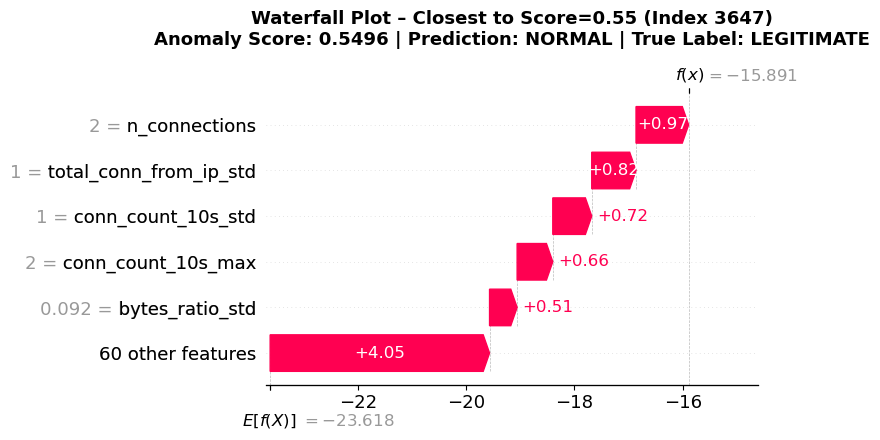

In [47]:
# CELDA 3: Closest to Score 0.6
name = "Closest to Score=0.55"
idx = instances[name]
shap_explanations[name] = plot_waterfall_and_explain(name, idx)

Plot 3:

- This sample exhibits moderate anomalous behavior. The majority of normal traffic shows 0 connection per window(scaled ; originally 1), as typical traffic to Consul is not very intensive. The value **n_connections = 2 (scaled; originally 3)** indicates higher intensity in this instance. Similarly, **total_conn_from_ip_std = 1 (scaled), conn_count_10s_std = 1, and max = 2** support this observation.

- A very low bytes_ratio_std suggests that all packets sent to Consul within this window were similar in size.

- The overall pattern resembles accelerated healthcheck traffic, possibly triggered when a service went down or immediately after it came back online.